In [77]:
import matplotlib as plt
import math, random, collections, itertools

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
def mdarray(dim: list):
    size = dim[0]
    dimss = len(dim)
    if dimss == 1:
        return [None]*size
    else:
        return [mdarray(dim[1:]) for _ in range(size)]

class Matrix():
    def __init__(self, metrix: list, values: list):
        self.matrix = mdarray(metrix)  # Сохраняем матрицу в атрибуте
        self.dims = metrix  # Сохраняем размерности
        self.values = values  # Сохраняем значения (если нужно)
        flat_values = values.copy()
        self._fill_matrix(self.matrix, flat_values)

    def _fill_matrix(self, arr, values):
        """Рекурсивно заполняет матрицу значениями."""
        for i in range(len(arr)):
            if isinstance(arr[i], list):
                self._fill_matrix(arr[i], values)
            else:
                if values:  # Если значения ещё остались
                    arr[i] = values.pop(0)

    def __repr__(self):
        """Возвращает строковое представление для вывода."""
        return f"{self.matrix}"

    def __str__(self):
        """Возвращает красивое строковое представление матрицы."""
        return str(self.matrix)
    def __getitem__(self, index):
        return self.matrix[index]
    def __setitem__(self, key, val):
        self.matrix[key] = val
    def __delitem__(self, key):
        self.matrix[key].pop()
    def __contains__(self, item):
        """Проверяет, содержится ли элемент в матрице."""
        def _contains_recursive(arr, target):
            for element in arr:
                if isinstance(element, list):
                    if _contains_recursive(element, target):
                        return True
                elif element == target:
                    return True
            return False
        return _contains_recursive(self.matrix, item)
    def __add__(self, other: 'Matrix') -> 'Matrix':
        if self.dims != other.dims:
            raise ValueError("Размерности матриц должны совпадать для сложения.")
        def add_rec(a, b):
            if isinstance(a, list):
                return [add_rec(a[i], b[i]) for i in range(len(a))]
            return a + b
        result = add_rec(self.matrix, other.matrix)
        flat = list(self._flatten(result))
        return Matrix(self.dims, flat)
    def _flatten(self, arr):
        for el in arr:
            if isinstance(el, list):
                yield from self._flatten(el)
            else:
                yield el
    def __sub__(self, other: 'Matrix') -> 'Matrix':
        if self.dims != other.dims:
            raise ValueError("Размерности матриц должны совпадать для вычитания.")
        def sub_rec(a, b):
            if isinstance(a, list):
                return [sub_rec(a[i], b[i]) for i in range(len(a))]
            return a - b
        result = sub_rec(self.matrix, other.matrix)
        flat = list(self._flatten(result))
        return Matrix(self.dims, flat)

    def __matmul__(self, other: 'Matrix') -> 'Matrix':
        # Матричное умножение A (n x m) @ B (m x p) = C (n x p)
        if len(self.dims) != 2 or len(other.dims) != 2:
            raise ValueError("Матричное умножение поддерживается только для 2D-матриц.")
        n, m = self.dims
        m2, p = other.dims
        if m != m2:
            raise ValueError("Число столбцов первой матрицы должно совпадать с числом строк второй.")
        # Вычисление C
        C = [[sum(self.matrix[i][k] * other.matrix[k][j] for k in range(m))
              for j in range(p)]
             for i in range(n)]
        flat = [elem for row in C for elem in row]
        return Matrix([n, p], flat)

    def dot(self, other: 'Matrix') -> float:
        if len(self.dims) != 1 or len(other.dims) != 1 or self.dims[0] != other.dims[0]:
            raise ValueError("dot() поддерживается только для векторов одинаковой длины.")
        return sum(self.matrix[i] * other.matrix[i] for i in range(self.dims[0]))
    def __mul__(self, scalar: float) -> 'Matrix':
        if not isinstance(scalar, (int, float)):
            raise ValueError("Умножение на объект не-скаляр не поддерживается.")
        def rec(a):
            if isinstance(a, list):
                return [rec(el) for el in a]
            return a * scalar
        result = rec(self.matrix)
        flat = list(self._flatten(result))
        return Matrix(self.dims, flat)
    __rmul__ = __mul__
    def mean(self):
        n=1
        me=0
        for i in self.dims:
            n*=i
        for i in self.values:
            me+=i
        return me/n
    def T(self):
        rows, cols = self.dims
        transposed = Matrix([cols, rows], [0]*(rows*cols))
        for i in range(rows):
            for j in range(cols):
                transposed[j][i] = self[i][j]
        return transposed
    def Tt(self, d=None):
        if d is None:
            if len(self.dims) != 2:
                raise ValueError("Для матриц выше 2D укажите оси транспонирования.")
            d = [1, 0]
        else:
            if len(d) != len(self.dims):
                raise ValueError("Количество осей не совпадает с размерностью.")
            if sorted(d) != list(range(len(self.dims))):
                raise ValueError("Оси должны быть уникальны и в диапазоне [0, размерность-1].")

        original_dims = self.dims
        n_dims = len(original_dims)
        new_dims = [original_dims[i] for i in d]

        indices = list(itertools.product(*[range(dim) for dim in original_dims]))
        new_values = [0] * len(self.values)

        original_strides = [1] * n_dims
        for i in reversed(range(n_dims - 1)):
            original_strides[i] = original_strides[i+1] * original_dims[i+1]

        new_strides = [1] * n_dims
        for i in reversed(range(n_dims - 1)):
            new_strides[i] = new_strides[i+1] * new_dims[i+1]

        for idx in indices:
            transposed_idx = tuple(idx[i] for i in d)
            original_flat = sum(idx[i] * original_strides[i] for i in range(n_dims))
            new_flat = sum(transposed_idx[i] * new_strides[i] for i in range(n_dims))
            new_values[new_flat] = self.values[original_flat]

        return Matrix(new_dims, new_values)


In [80]:
def gauss_solver(A: Matrix, B: Matrix, eps: float = 1e-12) -> Matrix:
    """
    Решает систему линейных уравнений A * X = B методом классического Гаусса для прямоугольных матриц.
    A: матрица размером n x m;
    B: правая часть размером n (вектор) или n x p (матрица).
    Возвращает Matrix размерности [m] или [m, p] с частным решением,
    где свободные переменные приравниваются к нулю.
    """
    if len(A.dims) != 2:
        raise ValueError("A должна быть двумерной матрицей.")
    n, m = A.dims
    if len(B.dims) == 1:
        if B.dims[0] != n:
            raise ValueError("Длина вектора B должна равняться числу строк A.")
        p = 1
        B_vals = [[B[i]] for i in range(n)]
    elif len(B.dims) == 2:
        if B.dims[0] != n:
            raise ValueError("Число строк B должно равняться числу строк A.")
        p = B.dims[1]
        B_vals = [row.copy() for row in B.matrix]
    else:
        raise ValueError("B должна быть вектором или матрицей.")
    aug = [A.matrix[i].copy() + B_vals[i] for i in range(n)]
    row = 0
    pivot_cols = []
    for col in range(m):
        sel = None
        for i in range(row, n):
            if abs(aug[i][col]) > eps:
                sel = i
                break
        if sel is None:
            continue
        aug[row], aug[sel] = aug[sel], aug[row]
        pivot_cols.append(col)
        for i in range(row + 1, n):
            factor = aug[i][col] / aug[row][col]
            aug[i] = [aug[i][j] - factor * aug[row][j] for j in range(m + p)]
        row += 1
        if row == n:
            break
    X = [[0] * p for _ in range(m)]
    for i in range(len(pivot_cols) - 1, -1, -1):
        col = pivot_cols[i]
        for j in range(p):
            rhs = aug[i][m + j]
            for k in pivot_cols[i+1:]:
                rhs -= aug[i][k] * X[k][j]
            X[col][j] = rhs / aug[i][col]
    if p == 1:
        flat = [X[i][0] for i in range(m)]
        return Matrix([m], flat)
    flat = [X[i][j] for i in range(m) for j in range(p)]
    return Matrix([m, p], flat)


Не используем CSR тк данные в дальнейшем будут отцентрованы и такой формат хранения будет не эффективен

Для:

PCA анализирует вариации данных. Смещение значений (например, если переменная измеряется от 100, а не от 0) не должно влиять на анализ.

Центрирование делает данные «нормированными» по расположению: они будут сосредоточены вокруг нуля, что критически важно для корректного расчета ковариационной матрицы.

In [81]:
def center_data(X: "Matrix"):
    mean = X.mean()
    v = X.values.copy()
    for i in range(len(X.values)-1):
        v[i] -= mean
    Xn = Matrix(X.dims, v)
    return Xn

Центирование(стандартизация)

Если переменные имеют разные единицы измерения или масштабы, переменная с большей дисперсией может доминировать в PCA.

Стандартизация особенно важна, когда признаки измеряются в разных единицах (например, рост в метрах и вес в кг).

В формуле вычисления марицы ковариаций указан неправильный порядок умножения

In [82]:
def covariance_matrix(X: "Matrix"):
    Xc = center_data(X)
    n = Xc.dims[0]
    return (1 / (n - 1)) * (Xc.T() @ Xc)


Ковариационная матрица показывает связи между признаками.

PCA ищет такие направления (комбинации признаков), вдоль которых данные изменяются больше всего — это определяется через ковариации.

In [83]:
def eigenval(C: Matrix, tol=1e-6) -> list[float]:
    if C.dims[0] != C.dims[1]:
        raise ValueError("Матрица должна быть квадратной.")
    n = C.dims[0]

    C = (C + C.T()) * 0.5  # Симметризация на всякий случай, если матрица не симметрична
    A = [[C[i][j] for j in range(n)] for i in range(n)]
    eps = 1e-12  # Минимальный порог
    def count_negatives(shift):
        d = [0] * n
        d[0] = A[0][0] - shift
        if abs(d[0]) < eps:
            d[0] = eps
        count = 1 if d[0] < 0 else 0
        for i in range(1, n):
            d[i] = A[i][i] - shift
            for j in range(i):
                if abs(d[j]) < eps:
                    continue
                d[i] -= (A[i][j] ** 2) / d[j]
            if abs(d[i]) < eps:
                d[i] = eps
            if d[i] < 0:
                count += 1
        return count
    max_val = max(abs(C[i][j]) for i in range(n) for j in range(n))
    a, b = -max_val - 1, max_val + 1
    eigenvalues = []
    for k in range(n):
        low, high = a, b
        while high - low > tol:
            mid = (low + high) / 2
            if count_negatives(mid) <= k:
                low = mid
            else:
                high = mid
        eigenvalues.append((low + high) / 2)
    return eigenvalues


Собственные векторы — это направления (оси) новых координат (главные компоненты).

Собственные значения показывают, сколько дисперсии (информации) содержится вдоль этих новых осей.

Упорядочив собственные векторы по убыванию собственных значений, мы получаем наиболее значимые направления в данных.

^ eps рассмотреть

In [84]:
#не работает полноценно и ищет только нулевые векторы теоретически правильное решение, которое не несет пользу
def find_egv_broke(C: Matrix, eigenvalues: list[float]) -> list["Matrix"]:
    if C.dims[0] != C.dims[1]:
        raise ValueError("Матрица должна быть квадратной.")
    n = C.dims[0]
    vectors = []
    for lam in eigenvalues:
        I = Matrix([n, n], [1 if i == j else 0 for i in range(n) for j in range(n)])
        A = C - lam * I
        b = Matrix([n, 1], [0] * n)
        try:
            x = gauss_solver(A, b)
        except Exception:
            x = Matrix([n, 1], [0] * n)
        vectors.append(x)

    return vectors

In [85]:
def inverse_iteration(C: Matrix, mu: float, eps=1e-8, max_iter=50) -> Matrix:
    """
    Находит собственный вектор для приближённого λ=mu методом инверсионной итерации
    (C - mu·I)⁻¹ x → нормировка → следующая итерация. + еще можно было сделать qr алгоритм, qr более стабилен,
    но мтод обратных итераций интуитивнее+ у меня получился, поэтому именно он
    Работает с векторами-1D (dims=[n]).
    """
    n = C.dims[0]
    # B = C - mu·I
    I = Matrix([n,n], [1 if i==j else 0 for i in range(n) for j in range(n)])
    B = C - mu * I

    import random, math
    # x₀ как 1D-вектор
    x = Matrix([n], [random.random() for _ in range(n)])
    # нормируем: x ← x / ||x||
    norm = math.sqrt(x.dot(x))
    x = x * (1.0 / norm)

    for _ in range(max_iter):
        # 1) решаем B·y = x
        y = gauss_solver(B, x)  # y — тоже Matrix([n], …)
        # 2) нормируем
        yn = math.sqrt(y.dot(y))
        if yn < eps:
            break
        y = y * (1.0 / yn)

        # 3) проверяем, что y ≈ x
        diff = math.sqrt(sum((y.matrix[i] - x.matrix[i])**2 for i in range(n)))
        x = y
        if diff < eps:
            break

    return x

def find_egv(C: Matrix, eigenvalues: list[float]) -> list[Matrix]:
    """
    Для каждого λ из списка возвращает собственный вектор,
    найденный inverse_iteration.
    """
    return [inverse_iteration(C, mu) for mu in eigenvalues]

In [86]:
def explained_variance_ratio(eigenvalues: list[float], k: int) -> float:
    if k > len(eigenvalues):
        raise ValueError("k не может быть больше числа собственных значений.")

    # 1) Отсечь отрицательные (численные артефакты)
    eigen_pos = [ev if ev > 0 else 0.0 for ev in eigenvalues]
    # 2) Отсортировать по убыванию (на случай, если не отсортированы)
    eigen_pos.sort(reverse=True)

    total_variance = sum(eigen_pos)
    if total_variance == 0:
        return 0.0

    top_k_variance = sum(eigen_pos[:k])
    return top_k_variance / total_variance


In [87]:
def pca(X: "Matrix", k: int) -> tuple[Matrix, float]:
    """
    Выполняет PCA-анализ: проецирует X на k главных компонент.

    :param X: Матрица данных [n_samples, n_features]
    :param k: Число главных компонент
    :return: (X_reduced, explained_variance_ratio)
    """
    X_centered = center_data(X)
    C = covariance_matrix(X_centered)
    eigenvalues = eigenval(C)
    eig_pairs = list(enumerate(eigenvalues))
    eig_pairs.sort(key=lambda x: x[1], reverse=True)
    sorted_values = [pair[1] for pair in eig_pairs]
    sorted_indices = [pair[0] for pair in eig_pairs]
    vecs_all = find_egv(C, sorted_values)
    top_vectors = [vecs_all[i] for i in range(k)]
    feature_dim = X.dims[1]
    P_vals = []
    for j in range(k):
        for i in range(feature_dim):
            P_vals.append(top_vectors[j].matrix[i])  # v_j[i]
    P = Matrix([feature_dim, k], P_vals)
    X_reduced = X_centered @ P
    ratio = explained_variance_ratio(sorted_values, k)

    return X_reduced, ratio


In [88]:
import matplotlib.pyplot as plt

def plot_pca_2d(X: 'Matrix', X_proj: 'Matrix'):
    """
    Визуализирует проекцию X на первые 2 компоненты PCA (X_proj).
    X — оригинальные данные (n×m), X_proj — проекция (n×2)
    """
    if X_proj.dims[1] != 2:
        raise ValueError("Для визуализации требуется проекция на 2 компоненты.")

    x_vals = [X_proj[i][0] for i in range(X_proj.dims[0])]
    y_vals = [X_proj[i][1] for i in range(X_proj.dims[0])]

    plt.figure(figsize=(6, 5))
    plt.scatter(x_vals, y_vals, color='teal', edgecolors='k')
    plt.title("PCA: проекция на первые 2 компоненты")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

Автоматический выбор К компонент

In [89]:
def auto_select_k(eigenvalues: list[float], threshold: float) -> int:
    """
    Выбирает минимальное k, при котором объясняется не менее threshold дисперсии.
    """
    total = sum(eigenvalues)
    cumulative = 0.0
    for i, val in enumerate(eigenvalues):
        cumulative += val
        if cumulative / total >= threshold:
            return i + 1
    return len(eigenvalues)


Мы хотим уменьшить размерность, оставляя только наиболее важные компоненты, содержащие наибольшую часть информации.

Выбор
𝑘
k часто делают так, чтобы сохранить, например, 90% дисперсии.

пса с доработками и автовыбором

In [90]:
def pca1(X: "Matrix", k: int = None, threshold: float = 0.885) -> tuple[Matrix, float, int]:
    """
    PCA-анализ: проекция данных X на k главных компонент.
    Если k не задан, выбирается автоматически по threshold (0.885 по умолчанию).
    Возвращает: (X_reduced, explained_variance_ratio, k)
    """
    X_centered = center_data(X)
    C = covariance_matrix(X_centered)
    eigenvalues = eigenval(C)
    eig_pairs = list(enumerate(eigenvalues))
    eig_pairs.sort(key=lambda x: x[1], reverse=True)
    sorted_values = [p[1] for p in eig_pairs]
    if k is None:
        k = auto_select_k(sorted_values, threshold)
    vecs_all = find_egv(C, sorted_values)
    top_vectors = [vecs_all[i] for i in range(k)]
    feature_dim = X.dims[1]
    P_vals = []
    for j in range(k):
        for i in range(feature_dim):
            P_vals.append(top_vectors[j].matrix[i])
    P = Matrix([feature_dim, k], P_vals)
    X_reduced = center_data(X) @ P
    ratio = explained_variance_ratio(sorted_values, k)

    return X_reduced, ratio, k


In [91]:
def reconstruction_error(X_orig: 'Matrix', X_recon: 'Matrix') -> float:
    """
    Вычисляет среднеквадратическую ошибку восстановления данных.

    :param X_orig: исходная матрица (n×m)
    :param X_recon: восстановленная матрица (n×m)
    :return: MSE (float)
    """
    if X_orig.dims != X_recon.dims:
        raise ValueError("Размерности X_orig и X_recon должны совпадать.")

    n, m = X_orig.dims
    total_sq_error = 0.0

    for i in range(n):
        for j in range(m):
            diff = X_orig[i][j] - X_recon[i][j]
            total_sq_error += diff ** 2

    return total_sq_error / (n * m)


In [92]:
import math
def handle_missing_values(X: 'Matrix') -> 'Matrix':
    """
    Обрабатывает пропущенные значения (NaN) в матрице:
    заменяет NaN в столбцах на среднее значение по этому столбцу.
    Возвращает новую матрицу без NaN.
    """
    n, m = X.dims
    column_sums = [0.0] * m
    column_counts = [0] * m
    for i in range(n):
        for j in range(m):
            val = X[i][j]
            if not math.isnan(val):
                column_sums[j] += val
                column_counts[j] += 1
    column_means = [column_sums[j] / column_counts[j] if column_counts[j] > 0 else 0.0for j in range(m)]
    filled_values = []
    for i in range(n):
        for j in range(m):
            val = X[i][j]
            filled_values.append(val if not math.isnan(val) else column_means[j])
    return Matrix([n, m], filled_values)


In [93]:
import random
import math
import numpy as np
from sklearn.decomposition import PCA #тут нампай и склерн только для сравнения моего  пса с пса из сторонней библиотеки

def add_noise_and_compare(X: 'Matrix', noise_level: float = 0.1):
    """
    Вход:
    X: матрица данных (n×m)
    noise_level: уровень шума (доля от стандартного отклонения)

    Выход: результаты PCA до и после добавления шума.
    """

    # Получаем значения из матрицы X
    values = np.array(X.values).reshape(X.dims)

    # Вычисляем стандартное отклонение данных
    std_dev = np.std(values)

    # Генерируем случайный шум
    noise = np.random.normal(0, noise_level * std_dev, values.shape)

    # Добавляем шум к данным
    noisy_values = values + noise

    # Создаем новую матрицу с шумом
    noisy_matrix = Matrix(X.dims, noisy_values.flatten().tolist())

    # Здесь может быть добавление PCA или другое сравнение (например, с использованием sklearn PCA)
    # Для примера:
    print("Исходная матрица:")
    print(X)

    print("Матрица с шумом:")
    print(noisy_matrix)

    # Пример анализа PCA
    pca = PCA(n_components=2)

    # Выполняем PCA до добавления шума
    pca.fit(values)
    print("PCA до шума:", pca.components_)

    # Выполняем PCA после добавления шума
    pca.fit(noisy_values)
    print("PCA после шума:", pca.components_)

    return noisy_matrix



In [94]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_22d(X: 'Matrix', X_proj: 'Matrix'):
    """
    Визуализирует проекцию X на первые 2 компоненты PCA (X_proj).
    Верхняя треть точек по PC2 — белые, средняя — синие, нижняя — красные.
    X — оригинальные данные (n×m), X_proj — проекция (n×2)
    """
    if X_proj.dims[1] != 2:
        raise ValueError("Для визуализации требуется проекция на 2 компоненты.")

    # Собираем координаты
    x_vals = np.array([X_proj[i][0] for i in range(X_proj.dims[0])])
    y_vals = np.array([X_proj[i][1] for i in range(X_proj.dims[0])])

    # Находим пороговые значения PC2 для деления на трети
    thr_low  = np.percentile(y_vals, 33.333)
    thr_high = np.percentile(y_vals, 66.667)

    # Назначаем цвет каждой точке
    colors = []
    for y in y_vals:
        if y >= thr_high:
            colors.append('white')  # верхняя треть
        elif y >= thr_low:
            colors.append('blue')   # средняя треть
        else:
            colors.append('red')    # нижняя треть

    # Рисуем
    plt.figure(figsize=(6, 5))
    plt.scatter(x_vals, y_vals, c=colors, edgecolors='k')
    plt.title("PCA: проекция на первые 2 компоненты")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


[2688.0, 26.0, 21.8, 112.1, 110.6, 12.2, 115.0, 66.0, 179.9, 70.5, 108.0, 11.6, 6.9, 3333.0]
[[2688.0, 26.0, 21.8, 112.1, 110.6, 12.2, 115.0, 66.0, 179.9, 70.5, 108.0, 11.6, 6.9, 3333.0], [233.0, 36.0, 21.9, 93.8, 122.7, 7.2, 95.0, 69.0, 231.2, 73.7, 105.9, 36.7, 3.3, 2430.0], [9099.0, 31.0, 31.5, 88.5, 177.5, 14.3, 150.0, 82.0, 205.9, 34.5, 144.5, 59.9, 4.6, 2289.0], [8652.0, 21.0, 30.6, 76.2, 141.8, 4.1, 105.0, 67.0, 214.2, 73.7, 143.0, 98.6, 6.7, 1920.0], [2842.0, 69.0, 27.0, 76.2, 91.1, 12.9, 136.0, 103.0, 197.3, 74.9, 130.1, 13.9, 3.6, 2588.0], [283.0, 24.0, 38.4, 107.8, 135.7, 5.4, 91.0, 76.0, 155.1, 53.9, 165.0, 61.7, 7.2, 1655.0], [7673.0, 48.0, 34.6, 115.2, 154.3, 12.8, 136.0, 94.0, 161.7, 43.2, 137.1, 45.4, 5.9, 1585.0], [1435.0, 53.0, 24.9, 91.0, 187.9, 11.3, 178.0, 71.0, 253.2, 32.9, 147.4, 67.3, 3.9, 3824.0], [8641.0, 54.0, 22.9, 106.8, 107.5, 7.2, 132.0, 100.0, 159.7, 62.9, 81.3, 40.3, 4.0, 3633.0], [9584.0, 50.0, 29.5, 118.2, 164.1, 12.5, 135.0, 95.0, 238.8, 66.4, 157.5,

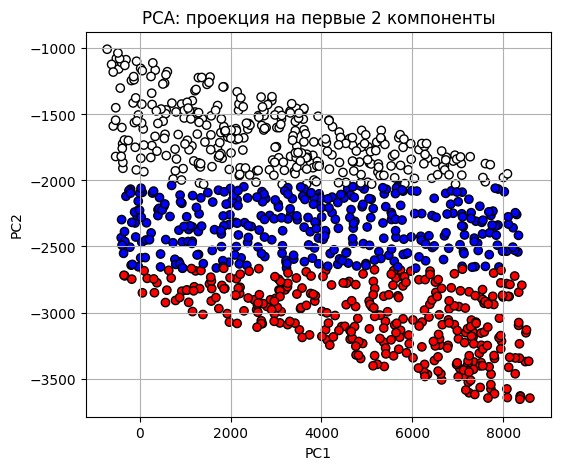

In [95]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/diabetes_dataset.csv")
df = df.drop(['Ethnicity', 'Sex', 'Physical_Activity_Level', 'Alcohol_Consumption','Smoking_Status','Family_History_of_Diabetes','Previous_Gestational_Diabetes'], axis=1)#чистим датасет от категориальных данных
# оставим 10000 случайных строк, чтобы наглядянее было видно распреедление
df = df.sample(n=1000, random_state=17)
data = [list(df.iloc[i]) for i in range(len(df))]
flat = [x for row in data for x in row]
Data = Matrix([len(data), df.shape[1]], flat)

print(Data[0])
print(Data.matrix)

X_proj, variance_ratio = pca(Data, k=2)

print("Проекция на главные компоненты:")
print( X_proj.matrix[0])
print("...")
print( X_proj.matrix[-1])

print(f"\nОбъяснённая дисперсия: {variance_ratio:.4f}")

plot_pca_22d(Data, X_proj)

PCA до добавления шума:
Объяснённая дисперсия: 0.9572946284773381


...............
----------------------------------------------------------------------
Ran 15 tests in 0.022s

OK


PCA после добавления шума:
Объяснённая дисперсия: 0.9209200637016818


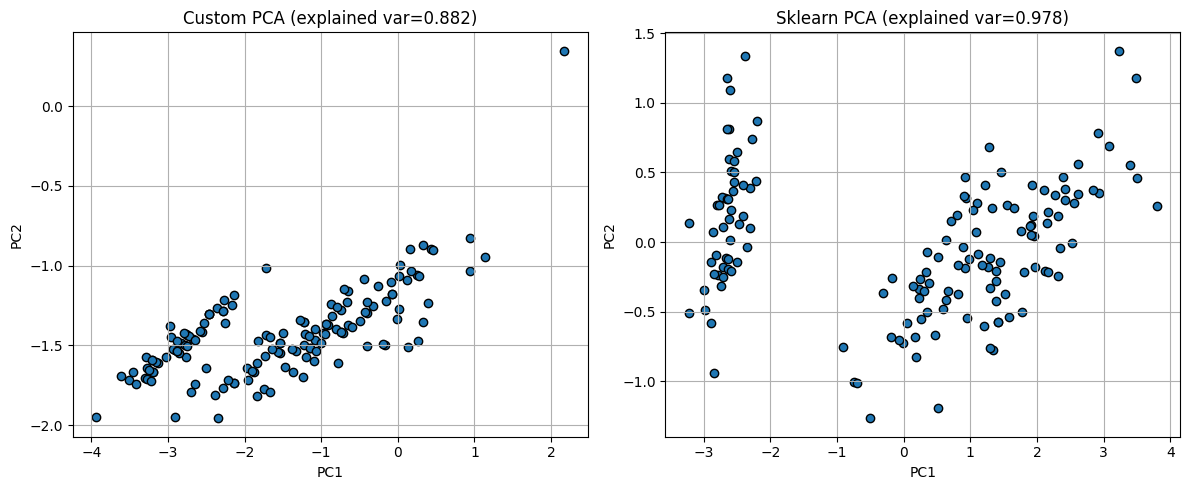

In [96]:
import nbformat # эта визуализация исключительно для того, чтобы посмотреть на несовершенность моего алгоритма и сравнить его с нампаем(там, к слову, используются совсем другие методы)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SKPCA
from sklearn.datasets import load_iris

# 1) Подгружаем определения из main.ipynb (только классы и функции, без примеров)
nb = nbformat.read('/content/drive/MyDrive/main.ipynb', as_version=4)
global_ns = globals()
for cell in nb.cells:
    if cell.cell_type == 'code':
        src = cell.source
        if 'read_csv' in src or '# Пример' in src or 'compare_pca_aligned' in src:
            continue
        exec(src, global_ns)

# 2) Загружаем датасет Iris
data = load_iris()
X_np = data.data

# 3) Конвертация в твой Matrix
X_matrix = Matrix([X_np.shape[0], X_np.shape[1]], X_np.flatten().tolist())

# 4) Получаем проекции
X_proj_custom, ratio_custom = pca(X_matrix, 2)
dims_custom = X_proj_custom.dims
vals_custom = np.array(X_proj_custom.values).reshape(dims_custom[0], dims_custom[1])

skpca = SKPCA(n_components=2)
X_proj_sk = skpca.fit_transform(X_np)
ratio_sk = skpca.explained_variance_ratio_.sum()

# 5) Рисуем два графика рядом
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(vals_custom[:, 0], vals_custom[:, 1], edgecolor='k')
plt.title(f"Custom PCA (explained var={ratio_custom:.3f})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_proj_sk[:, 0], X_proj_sk[:, 1], edgecolor='k')
plt.title(f"Sklearn PCA (explained var={ratio_sk:.3f})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.tight_layout()
plt.show()


In [97]:
import random
import math

def add_noise_and_compare(X: 'Matrix', noise_level: float = 0.1):
    """
    Вход:
    X: матрица данных (n×m)
    noise_level: уровень шума (доля от стандартного отклонения)

    Выход: результаты PCA до и после добавления шума.
    """

    def normal_random():
        """Генерация случайного числа из нормального распределения с нулевым средним и стандартным отклонением 1."""
        u1 = random.random()
        u2 = random.random()
        z0 = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        return z0
    values = X.values
    dims = X.dims
    matrix = []
    idx = 0
    for i in range(dims[0]):
        row = values[idx:idx+dims[1]]
        matrix.append(row)
        idx += dims[1]
    mean = sum(values) / len(values)
    variance = sum((x - mean) ** 2 for x in values) / len(values)
    std_dev = math.sqrt(variance)
    noisy_matrix = []
    for i in range(dims[0]):
        noisy_row = []
        for j in range(dims[1]):
            noise = normal_random() * noise_level * std_dev
            noisy_row.append(matrix[i][j] + noise)
        noisy_matrix.append(noisy_row)
    noisy_values = [item for sublist in noisy_matrix for item in sublist]
    noisy_matrix_obj = Matrix(dims, noisy_values)
    X_reduced, ratio = pca(X, k=2)
    print("PCA до добавления шума:")
    print("Объяснённая дисперсия:", ratio)

    # PCA после добавления шума
    X_reduced_noisy, ratio_noisy = pca(noisy_matrix_obj, k=2)
    print("PCA после добавления шума:")
    print("Объяснённая дисперсия:", ratio_noisy)

    return 0


In [98]:
add_noise_and_compare(Data)

PCA до добавления шума:
Объяснённая дисперсия: 0.9572946284773381
PCA после добавления шума:
Объяснённая дисперсия: 0.925055207654318


0

In [99]:
import unittest
import math

# Импортируем тестируемые объекты
#from main import mdarray, Matrix, gauss_solver, eigenval, pca

class TestMdarray(unittest.TestCase):
    def test_1d(self):
        # Одномерный массив из None
        self.assertEqual(mdarray([3]), [None, None, None])

    def test_2d(self):
        arr = mdarray([2, 3])
        # Должна быть вложенная структура 2x3
        self.assertEqual(len(arr), 2)
        for row in arr:
            self.assertEqual(len(row), 3)
            self.assertTrue(all(el is None for el in row))

    def test_zero_dim(self):
        # Размерность 0 вернёт пустой список
        self.assertEqual(mdarray([0]), [])

class TestMatrixBasic(unittest.TestCase):
    def setUp(self):
        # Матрица 2x2 со значениями 1,2,3,4
        self.m = Matrix([2, 2], [1, 2, 3, 4])

    def test_dims_and_values(self):
        self.assertEqual(self.m.dims, [2, 2])
        # После заполнения matrix хранит те же значения
        self.assertEqual(self.m.values, [1, 2, 3, 4])
        self.assertEqual(self.m.matrix, [[1, 2], [3, 4]])

    def test_repr(self):
        # repr должен возвращать строку вложенного списка
        self.assertEqual(repr(self.m), '[[1, 2], [3, 4]]')

    def test_contains(self):
        self.assertTrue(3 in self.m)
        self.assertFalse(5 in self.m)

    def test_delitem(self):
        # Удаляем последний элемент первой строки
        del self.m[0]
        self.assertEqual(self.m.matrix[0], [1])

class TestMatrixArithmetic(unittest.TestCase):
    def test_add_sub(self):
        a = Matrix([2, 2], [1, 1, 1, 1])
        b = Matrix([2, 2], [2, 3, 4, 5])
        c = a + b
        d = b - a
        self.assertEqual(c.matrix, [[3, 4], [5, 6]])
        self.assertEqual(d.matrix, [[1, 2], [3, 4]])

    def test_mul_scalar(self):
        a = Matrix([2, 2], [1, 2, 3, 4])
        b = a * 2
        self.assertEqual(b.matrix, [[2, 4], [6, 8]])
        # rmul
        c = 3 * a
        self.assertEqual(c.matrix, [[3, 6], [9, 12]])

    def test_dot(self):
        v1 = Matrix([3], [1, 2, 3])
        v2 = Matrix([3], [4, 5, 6])
        # 1*4+2*5+3*6 = 32
        self.assertEqual(v1.dot(v2), 32)
        with self.assertRaises(ValueError):
            v1.dot(Matrix([2], [1, 2]))

class TestMatrixMeanTranspose(unittest.TestCase):
    def test_mean(self):
        m = Matrix([2, 2], [1, 3, 5, 7])
        # Среднее (1+3+5+7)/4 = 4
        self.assertEqual(m.mean(), 4)

    def test_transpose(self):
        m = Matrix([2, 3], [1, 2, 3, 4, 5, 6])
        mt = m.T()  # транспонирование по умолчанию d=[1,0]
        # Должна быть матрица 3x2: [[1,4],[2,5],[3,6]]
        self.assertEqual(mt.dims, [3, 2])
        self.assertEqual(mt.matrix, [[1, 4], [2, 5], [3, 6]])

class TestLinearAlgebra(unittest.TestCase):
    def test_gauss_solver(self):
        # Решаем систему x + y = 3, x - y = 1
        A = Matrix([2, 2], [1, 1, 1, -1])
        B = Matrix([2, 1], [3, 1])
        X = gauss_solver(A, B)
        # Решение x=2, y=1
        self.assertAlmostEqual(X.matrix[0], 2)
        self.assertAlmostEqual(X.matrix[1], 1)

    def test_eigenval(self):
        # Для диагональной матрицы eigenvalues ≈ диагональ
        D = Matrix([3, 3], [1,0,0, 0,2,0, 0,0,3])
        vals = eigenval(D)
        # Сортируем и сравниваем с допуском
        vals_sorted = sorted(vals)
        expected = [1, 2, 3]
        self.assertEqual(len(vals_sorted), len(expected))
        for v, e in zip(vals_sorted, expected):
            self.assertAlmostEqual(v, e, places=6)

    def test_pca(self):
        # Простые точки на оси x: дисперсия по x, k=1
        data = Matrix([3, 2], [1, 0, 2, 0, 3, 0])  # 3 образца, 2 признака
        X_red, ratio = pca(data, k=1)
        # Ожидаем размерность [n_samples, k]
        self.assertEqual(X_red.dims, [3, 1])
        # Доля объясненной дисперсии между 0 и 1
        self.assertTrue(0 <= ratio <= 1)

if __name__ == '__main__':
    # игнорируем аргументы IPython
    unittest.main(argv=['first-arg-is-ignored'], exit=False)


...............
----------------------------------------------------------------------
Ran 15 tests in 0.017s

OK


## Доказательство того, что оптимальные направления PCA совпадают с собственными векторами матрицы ковариаций

### 1. Постановка задачи PCA

Пусть дана выборка $X = \{\mathbf{x}_1, \dots, \mathbf{x}_N\} \subset \mathbb{R}^d$. Обозначим средний вектор:
$$
\bar{\mathbf{x}} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i,
$$

а матрицу ковариаций — как
$$
\Sigma = \frac{1}{N} \sum_{i=1}^N (\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^\top.
$$

Цель PCA — найти такое направление (единичный вектор) $\mathbf{w} \in \mathbb{R}^d$, что дисперсия проекций точек на это направление максимальна. То есть, максимизировать:

$$
\text{Var}(\mathbf{w}^\top \mathbf{x}) \quad \text{при условии } \|\mathbf{w}\| = 1.
$$

---

### 2. Дисперсия проекций через $\Sigma$

Обозначим $y_i = \mathbf{w}^\top \mathbf{x}_i$. Тогда:

$$
\text{Var}(y) = \frac{1}{N} \sum_{i=1}^N (y_i - \bar{y})^2,
$$

где $\bar{y} = \mathbf{w}^\top \bar{\mathbf{x}}$. Подставим $y_i$:

$$
\text{Var}(y) = \frac{1}{N} \sum_{i=1}^N \left( \mathbf{w}^\top (\mathbf{x}_i - \bar{\mathbf{x}}) \right)^2 = \mathbf{w}^\top \Sigma \mathbf{w}.
$$

Таким образом, задача сводится к:

$$
\max_{\|\mathbf{w}\| = 1} \mathbf{w}^\top \Sigma \mathbf{w}.
$$

---

### 3. Метод Лагранжа

Рассмотрим функцию Лагранжа:

$$
L(\mathbf{w}, \lambda) = \mathbf{w}^\top \Sigma \mathbf{w} - \lambda (\mathbf{w}^\top \mathbf{w} - 1).
$$

Условие стационарной точки:

$$
\frac{\partial L}{\partial \mathbf{w}} = 2\Sigma \mathbf{w} - 2\lambda \mathbf{w} = 0
\quad \Rightarrow \quad \Sigma \mathbf{w} = \lambda \mathbf{w}.
$$

То есть $\mathbf{w}$ — собственный вектор матрицы $\Sigma$, а $\lambda$ — соответствующее собственное значение.

---

### 4. Вывод

Таким образом, оптимальное направление $\mathbf{w}$ — это собственный вектор $\Sigma$, соответствующий наибольшему собственному значению. Следовательно, главные компоненты PCA — это собственные векторы матрицы ковариаций, отсортированные по убыванию собственных значений.
